# Практическая работа №3

In [549]:
from tkinter.font import names

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import alpha
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import optuna

In [550]:
data = pd.read_csv("data_sets/practice3.csv")

In [551]:
data

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959,3.080,8.381,9.781,3.763,-0.783,-1.257,-1.723,0.650,0.860,0.887,0.958,0.055,unstable
1,9.304,4.903,3.048,1.369,5.068,-1.940,-1.873,-1.255,0.413,0.862,0.562,0.782,-0.006,stable
2,8.972,8.848,3.046,1.215,3.405,-1.207,-1.277,-0.920,0.163,0.767,0.839,0.110,0.003,unstable
3,0.716,7.670,4.487,2.341,3.964,-1.027,-1.939,-0.997,0.446,0.977,0.929,0.363,0.029,unstable
4,3.134,7.609,4.944,9.858,3.526,-1.126,-1.846,-0.554,0.797,0.455,0.657,0.821,0.050,unstable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.930,9.488,2.377,6.188,3.343,-0.658,-1.449,-1.236,0.602,0.780,0.814,0.608,0.024,unstable
9996,3.392,1.275,2.955,6.895,4.350,-1.664,-0.952,-1.733,0.502,0.567,0.286,0.366,-0.026,stable
9997,2.364,2.842,8.776,1.009,4.300,-1.381,-0.944,-1.975,0.488,0.987,0.149,0.146,-0.032,stable
9998,9.632,3.994,2.757,7.821,2.515,-0.966,-0.650,-0.899,0.365,0.588,0.889,0.818,0.038,unstable


In [552]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


### Статистический анализ

In [553]:
data.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5.250,5.250,5.250,5.250,3.750,-1.250,-1.250,-1.250,0.525,0.525,0.525,0.525,0.016
std,2.743,2.743,2.743,2.743,0.752,0.433,0.433,0.433,0.274,0.274,0.274,0.274,0.037
min,0.501,0.500,0.501,0.500,1.583,-2.000,-2.000,-2.000,0.050,0.050,0.050,0.050,-0.081
25%,2.875,2.875,2.876,2.875,3.218,-1.625,-1.625,-1.625,0.288,0.288,0.288,0.287,-0.016
50%,5.250,5.250,5.250,5.250,3.751,-1.250,-1.250,-1.250,0.525,0.525,0.525,0.525,0.017
75%,7.625,7.625,7.625,7.625,4.282,-0.875,-0.875,-0.875,0.762,0.762,0.762,0.762,0.045
max,9.999,10.000,9.999,9.999,5.864,-0.500,-0.500,-0.500,1.000,1.000,1.000,1.000,0.109


<Figure size 640x480 with 0 Axes>

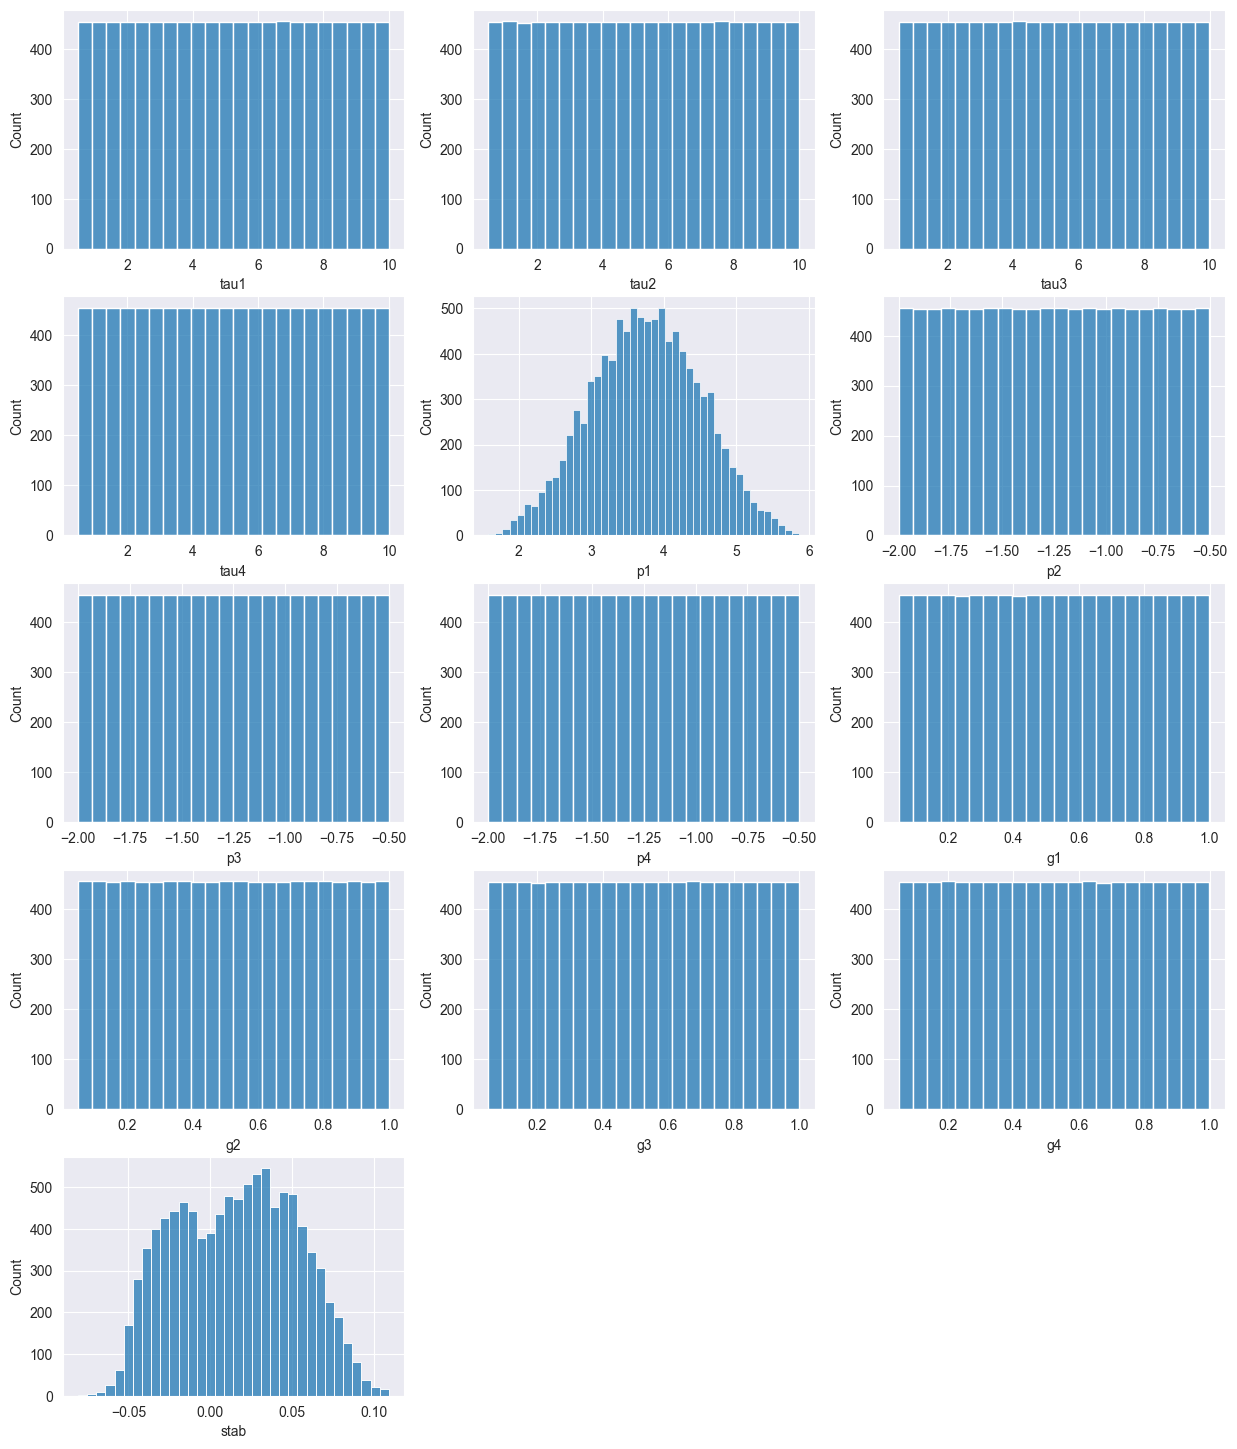

In [554]:
numeric_columns = data.select_dtypes(include=['number']).columns
plt.subplots_adjust(wspace=0.9, hspace=0.9)
fig, ax = plt.subplots(5, 3, figsize=(15, 18))
axes = ax.flatten()
for ax, column in zip(axes, numeric_columns):
    sns.histplot(data=data[column], ax=ax)


axes[-1].set_visible(False)
axes[-2].set_visible(False)

### Анализ выбросов

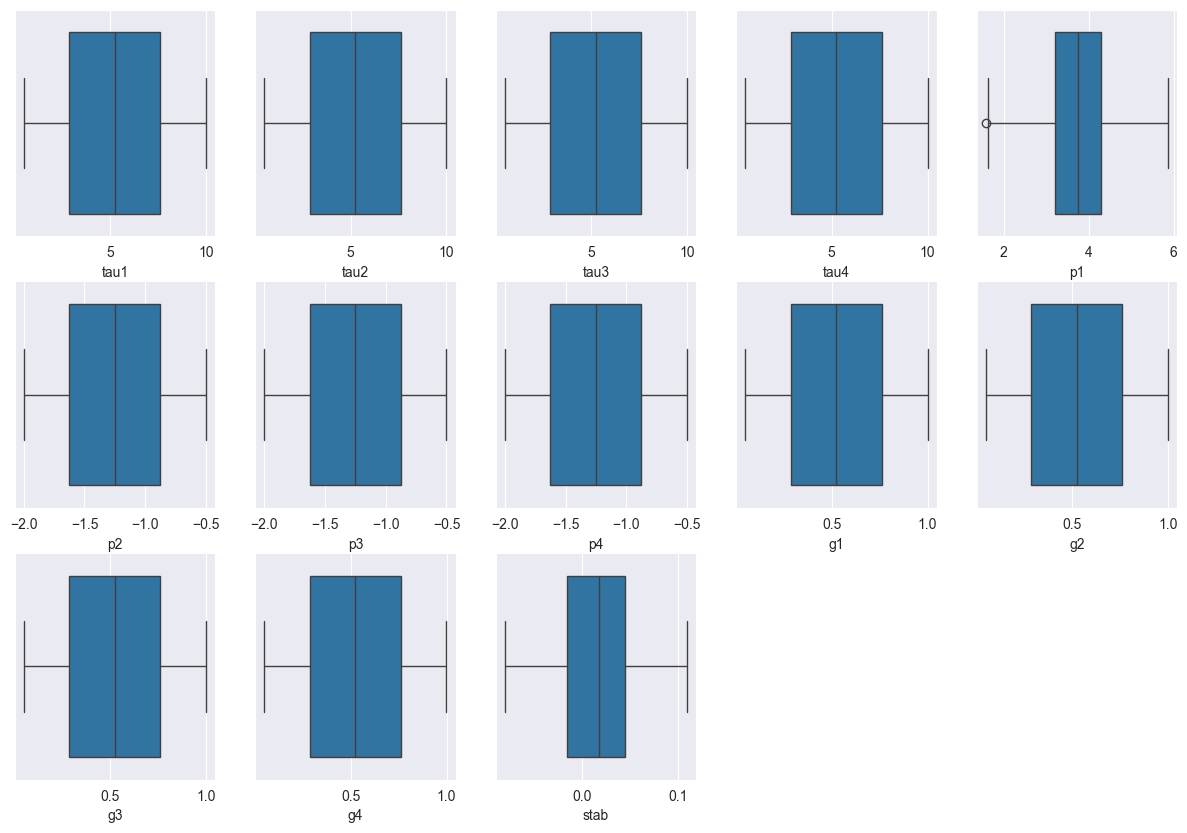

In [555]:
numeric_columns = data.select_dtypes(include=['number']).columns
fig, ax = plt.subplots(3, 5, figsize=(15, 10))
axes = ax.flatten()
for ax, column in zip(axes, numeric_columns):
    sns.boxplot(x = data[column], ax=ax)

axes[-1].set_visible(False)
axes[-2].set_visible(False)

<Axes: ylabel='p1'>

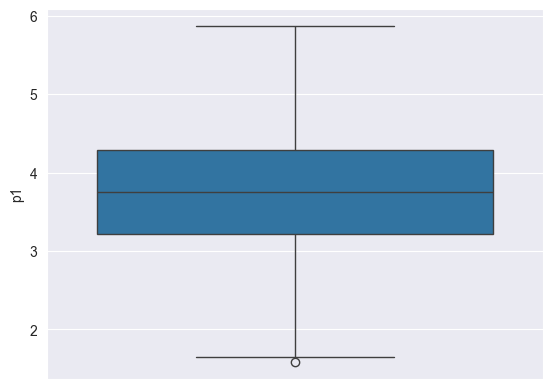

In [556]:
sns.boxplot(data["p1"])

In [557]:
iqr = data["p1"].quantile(0.75) - data["p1"].quantile(0.25)

data[data["p1"] <= 1.5 * iqr]

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
6273,6.698,7.861,9.333,2.434,1.583,-0.504,-0.572,-0.507,0.642,0.868,0.494,0.411,0.057,unstable


### Кодирование признаков

In [558]:
data["stabf"] = data["stabf"].map({"stable": 1, "unstable": 0})

### Корреляционный анализ

In [559]:
vif_data = pd.DataFrame()

vif_data["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]

vif_data["Features"] = data.columns

vif_data

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF,Features
0,4.594,tau1
1,4.560,tau2
2,4.580,tau3
3,4.518,tau4
4,inf,p1
5,inf,p2
6,inf,p3
7,inf,p4
8,4.632,g1
9,4.675,g2


<Axes: >

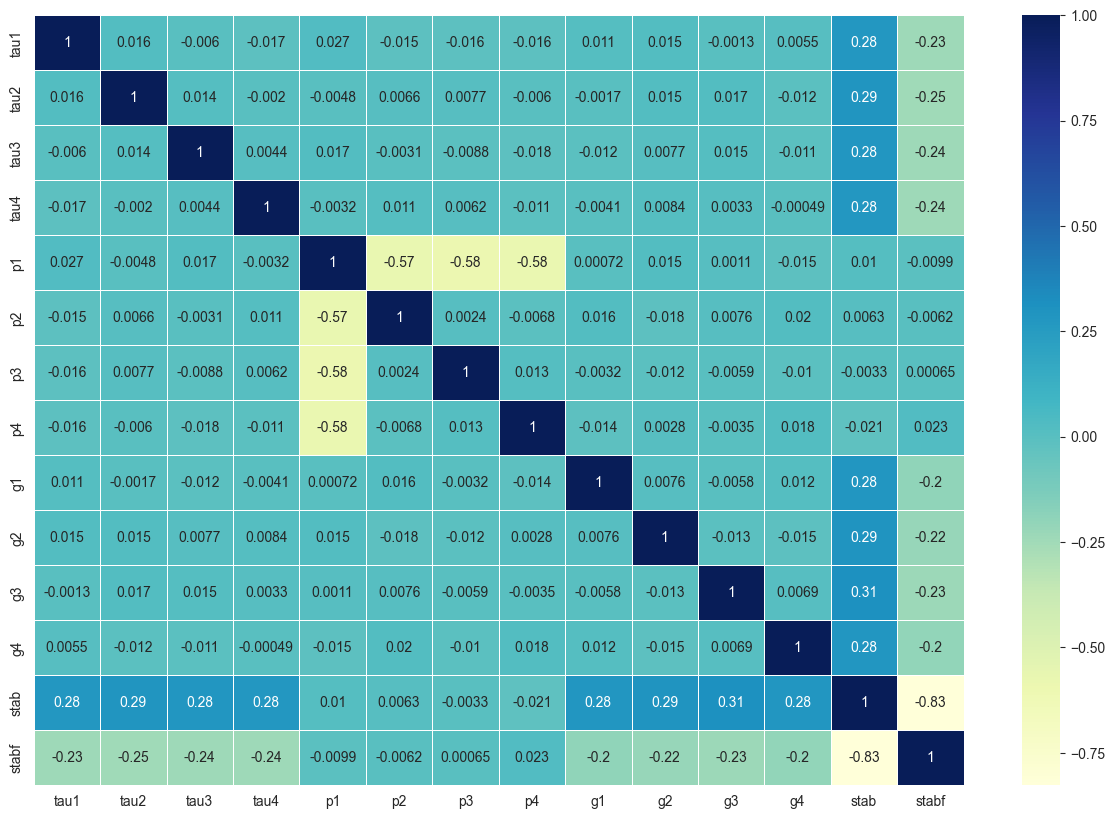

In [560]:
plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(numeric_only = True), annot=True, cmap="YlGnBu", linewidths=.5 )

### Масштабирование

In [561]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[numeric_columns])

scaled_df = pd.DataFrame(scaled_data, index=data[numeric_columns].index, columns=data[numeric_columns].columns)
scaled_df = pd.concat([scaled_df, data["stabf"]], axis=1)

## Обучение модели регрессии

Прежде, чем приступить к обучению моделей, сделаем несколько вспомогательных инструментов для избежания дублирования кода.

Функция `get_metrics` возвращает список из рассчитанных метрических показателей для предсказанных и истинных значений.

In [562]:
def get_metrics(y_test, y_predicted, print_results=False):
    names_of_metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]
    results = [
        r2_score(y_test, y_predicted),
        mean_squared_error(y_test, y_predicted),
        root_mean_squared_error(y_test, y_predicted),
        mean_absolute_error(y_test, y_predicted),
        mean_absolute_percentage_error(y_test, y_predicted)
    ]
    if print_results:
        for name, result in zip(names_of_metrics, results):
            print(f"{name}: {result}")
    return results

Функция `input_into_the_tables` будет использоваться для вставки полученных значений метрик в результирующую таблицу со всеми моделями.

In [563]:
def input_metrics_into_the_table(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_test_y, y_test,
                          train_and_test_comparing):
    sk_learn_test_metrics = get_metrics(y_test, predict_on_test_y)

    sk_learn_train_metrics = get_metrics(y_train, predict_on_train_y)

    train_and_test_comparing.loc[name_of_model] = sk_learn_train_metrics + sk_learn_test_metrics

Функция `train_models_with_reg` обучает модели с L1, L2 и ElasticNet регуляризациями с использованием GridSearch, RandomSearch, Optuna и возвращает полученные модели в словаре.

In [564]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def train_models_with_reg(X_train, y_train, X_test, y_test):

    result={}
    alpha_range = np.logspace(-10, 10).tolist()

    types_of_reg = {
        "L1": {
            "reg": Lasso,
            "param_grid": {"alpha": alpha_range}
        },
        "L2":
            {
                "reg": Ridge,
                "param_grid": {"alpha": alpha_range}
            },
        "EN":
            {
                "reg": ElasticNet,
                "param_grid":{
                        "alpha": np.logspace(-10, 10).tolist(),
                        "l1_ratio": np.arange(0.1, 1, 0.1).tolist()
                }

            }

    }

    for name, reg_info in types_of_reg.items():
        param_grid = reg_info["param_grid"]
        type_of_reg = reg_info["reg"]
        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator=type_of_reg(),
            scoring="neg_mean_squared_error",
            cv=4
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=type_of_reg(),
            scoring="neg_mean_squared_error",
            random_state=42,
            cv=4
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            params = {"alpha": trial.suggest_float('alpha', 1e-10, 1e10, log=True)}
            if name == "EN":
                params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.1, 1)

            model = type_of_reg(**params)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            return mse

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=100, show_progress_bar=False)

        optuna_model = type_of_reg(**study.best_params)
        optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": optuna_model,
            "best_params": study.best_params
        }

    return result


Ниже происходит создание датафрейма для хранения метрик.

In [565]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Train Data", "Test Data"],
    metrics
])

train_and_test_comparing = pd.DataFrame(columns=columns)
pd.options.display.float_format = '{:.3f}'.format
train_and_test_comparing

Empty DataFrame
Columns: [(Train Data, R2), (Train Data, MSE), (Train Data, RMSE), (Train Data, MAE), (Train Data, MAPE), (Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

In [566]:
X = scaled_df.drop("stab", axis=1)
y = scaled_df["stab"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=13)

Для начала обучим модель множественной регрессии без регуляризации.

### Множественная регрессия без регуляризации

In [567]:
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

simple_model.coef_

array([ 0.09602211,  0.10298152,  0.10233992,  0.1021518 ,  0.00081964,
       -0.00216663, -0.00077375,  0.00060033,  0.11534925,  0.11635627,
        0.12463558,  0.11503031, -0.21709393])

In [568]:
simple_model_train_predict = simple_model.predict(X_train)
simple_model_test_predict = simple_model.predict(X_test)

input_metrics_into_the_table(
    "Linear regression without regularization",
    simple_model_train_predict, y_train,
    simple_model_test_predict, y_test,
    train_and_test_comparing
)

train_and_test_comparing.loc["Linear regression without regularization"]

Train Data  R2                0.817
            MSE               0.007
            RMSE              0.083
            MAE               0.067
            MAPE   182756180188.672
Test Data   R2                0.811
            MSE               0.007
            RMSE              0.084
            MAE               0.067
            MAPE              0.161
Name: Linear regression without regularization, dtype: float64

Модель одинаково хорошо показывает себя как на трейн выборке, так и на тестовой выборке. Попробуем применить регуляризацию для модели.

<Axes: ylabel='stab'>

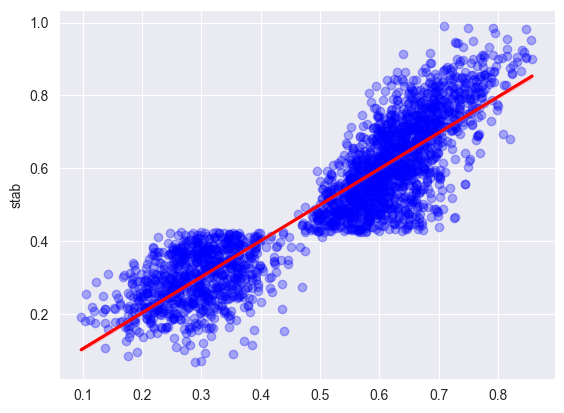

In [582]:
sns.regplot(x = simple_model_test_predict, y=y_test, line_kws={"color": "r"}, scatter_kws={"color": "b", "alpha": 0.3})

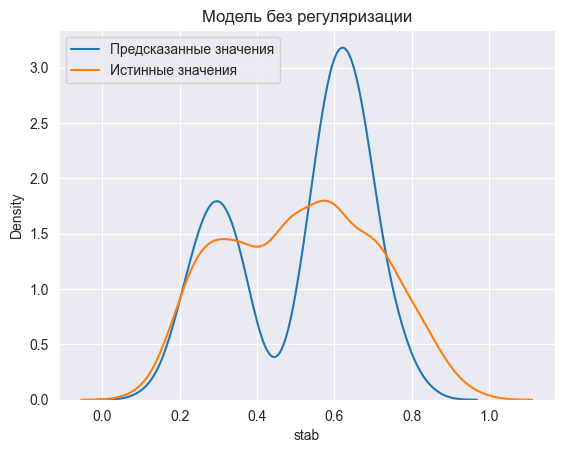

In [570]:
sns.kdeplot(simple_model_test_predict, label="Предсказанные значения")
sns.kdeplot(y_test, label="Истинные значения")

plt.title("Модель без регуляризации")
plt.legend()

### Множественная регрессия с регуляризацией

Для начала с помощью кастомной функции получим модели с видами регуляризаций L1, L2, ElasticNet. В дальнейшем рассмотрим каждый вид регуляризации отдельно.

In [571]:
models_with_regularization = train_models_with_reg(X_train, y_train, X_test, y_test)

#### L1 регуляризация

In [572]:
l1_models = models_with_regularization["L1"]
names = ["GridSearch", "RandomSearch", "Optuna"]

for name, model_dict in zip(names, l1_models.values()):
    print(f"Способ подбора параметров: {name}")
    print(model_dict["best_params"])


Способ подбора параметров: GridSearch
{'alpha': 0.0001325711365590111}
Способ подбора параметров: RandomSearch
{'alpha': 2.0235896477251556e-05}
Способ подбора параметров: Optuna
{'alpha': 6.823660854368952e-05}


Видим, что оптимальные параметры получились примерно одинаковыми с точностью до 5 знаков после запятой. Попробуем использовать модель с параметрами, вычисленными GridSearch.

In [573]:
l1_multiple_model = l1_models["GridSearch"]["model"]

l1_multiple_model.coef_

array([ 0.09376769,  0.1006843 ,  0.10004479,  0.09980301,  0.        ,
       -0.00082404, -0.        ,  0.        ,  0.11312478,  0.11417125,
        0.12236369,  0.11278133, -0.21895511])

В результате применения Lasso-регуляризации значения весов уменьшились. Некоторые из весов обратились в ноль из-за наличия мультиколлинеарности.

In [574]:
l1_multiple_model_train_predict = l1_multiple_model.predict(X_train)
l1_multiple_model_test_predict = l1_multiple_model.predict(X_test)

input_metrics_into_the_table(
    "Linear regression with Lasso regularization",
    l1_multiple_model_train_predict, y_train,
    l1_multiple_model_test_predict, y_test,
    train_and_test_comparing
)

train_and_test_comparing

Train Data                    \
                                                    R2   MSE  RMSE   MAE   
Linear regression without regularization         0.817 0.007 0.083 0.067   
Linear regression with Lasso regularization      0.817 0.007 0.083 0.067   

                                                             Test Data        \
                                                        MAPE        R2   MSE   
Linear regression without regularization    182756180188.672     0.811 0.007   
Linear regression with Lasso regularization 183171554023.028     0.811 0.007   

                                                               
                                             RMSE   MAE  MAPE  
Linear regression without regularization    0.084 0.067 0.161  
Linear regression with Lasso regularization 0.084 0.067 0.161

В результате применения L1-регуляризации показатели метрик практически не изменились.

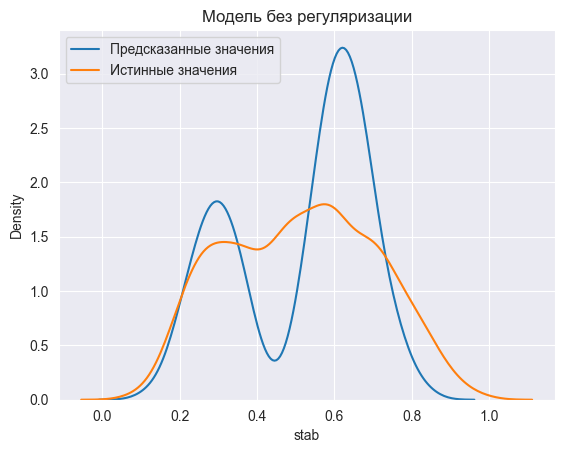

In [580]:
sns.kdeplot(l1_multiple_model_test_predict, label="Предсказанные значения")
sns.kdeplot(y_test, label="Истинные значения")

plt.title("Модель без регуляризации")
plt.legend()

#### L2 регуляризация

In [575]:
l2_models = models_with_regularization["L2"]
names = ["GridSearch", "RandomSearch", "Optuna"]

for name, model_dict in zip(names, l2_models.values()):
    print(f"Способ подбора параметров: {name}")
    print(model_dict["best_params"])

Способ подбора параметров: GridSearch
{'alpha': 0.6250551925273976}
Способ подбора параметров: RandomSearch
{'alpha': 0.005689866029018305}
Способ подбора параметров: Optuna
{'alpha': 1.0502180122082175e-10}


Фреймворк Optuna показал в качестве результата наименьшее значение гиперпараметра, а GridSearch и RandomSearch вычислили одинаковые значения гиперпараметра.

In [576]:
l2_multiple_model = l2_models["GridSearch"]["model"]

print(simple_model.coef_, l2_multiple_model.coef_, sep="\n")

[ 0.09602211  0.10298152  0.10233992  0.1021518   0.00081964 -0.00216663
 -0.00077375  0.00060033  0.11534925  0.11635627  0.12463558  0.11503031
 -0.21709393]
[ 0.09590322  0.10285585  0.10221345  0.10202447  0.00082006 -0.00216035
 -0.00077978  0.00059888  0.11521252  0.11621971  0.124488    0.11489149
 -0.21715811]


Заметим, что веса модели с L2 регуляризацией немного уменьшились в сравнении с весами модели без регуляризации.

In [577]:
l2_multiple_model_train_predict = l2_multiple_model.predict(X_train)
l2_multiple_model_test_predict = l2_multiple_model.predict(X_test)

input_metrics_into_the_table(
    "Linear regression with Ridge regularization",
    l2_multiple_model_train_predict, y_train,
    l2_multiple_model_test_predict, y_test,
    train_and_test_comparing
)
train_and_test_comparing

Train Data                    \
                                                    R2   MSE  RMSE   MAE   
Linear regression without regularization         0.817 0.007 0.083 0.067   
Linear regression with Lasso regularization      0.817 0.007 0.083 0.067   
Linear regression with Ridge regularization      0.817 0.007 0.083 0.067   

                                                             Test Data        \
                                                        MAPE        R2   MSE   
Linear regression without regularization    182756180188.672     0.811 0.007   
Linear regression with Lasso regularization 183171554023.028     0.811 0.007   
Linear regression with Ridge regularization 182780307651.182     0.811 0.007   

                                                               
                                             RMSE   MAE  MAPE  
Linear regression without regularization    0.084 0.067 0.161  
Linear regression with Lasso regularization 0.084 0.067 0.161  
Linear regression with Ridge regularization 0.084 0.067 0.161

Модели с Lasso и Ridge регуляризациями в целом показывают одинаковые результаты. Их отличие лишь в метрике MAPE как для тестовых, так и для обучающих данных - в L2 регуляризации эта метрика уменьшилась.

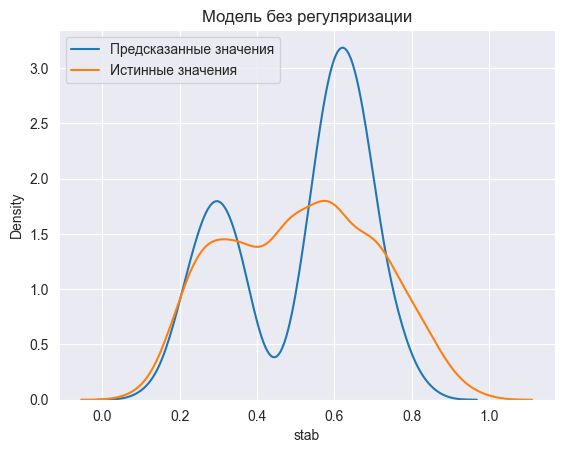

In [581]:
sns.kdeplot(l2_multiple_model_test_predict, label="Предсказанные значения")
sns.kdeplot(y_test, label="Истинные значения")

plt.title("Модель без регуляризации")
plt.legend()

#### Elastic Net регуляризация

In [578]:
elastic_net_multiple_models = models_with_regularization["EN"]

for name, model_dict in zip(names, elastic_net_multiple_models.values()):
    print(f"Способ подбора параметров: {name}")
    print(model_dict["best_params"])


Способ подбора параметров: GridSearch
{'alpha': 0.0001325711365590111, 'l1_ratio': 0.9}
Способ подбора параметров: RandomSearch
{'l1_ratio': 0.1, 'alpha': 2.0235896477251556e-05}
Способ подбора параметров: Optuna
{'alpha': 7.191839334007088e-05, 'l1_ratio': 0.7946079929525673}


Заметим, что Optuna и GridSearch показали примерно одинаковые результаты для параметров `alpha` и `l1_ratio`. RandomSearch показал примерно тот же результат для `alpha`, но меньший параметр для `l1_ratio`. Попробуем получить предсказания с помощью полученных моделей и посмотрим на метрики.

In [579]:
for name in names:
    model = elastic_net_multiple_models[name]["model"]

    train_predict = model.predict(X_train)
    test_predict = model.predict(X_test)

    input_metrics_into_the_table(
        f"Linear regression with Elastic Net (get with {name})",
        train_predict, y_train,
        test_predict, y_test,
        train_and_test_comparing
    )

train_and_test_comparing

Train Data              \
                                                           R2   MSE  RMSE   
Linear regression without regularization                0.817 0.007 0.083   
Linear regression with Lasso regularization             0.817 0.007 0.083   
Linear regression with Ridge regularization             0.817 0.007 0.083   
Linear regression with Elastic Net (get with Gr...      0.817 0.007 0.083   
Linear regression with Elastic Net (get with Ra...      0.817 0.007 0.083   
Linear regression with Elastic Net (get with Op...      0.817 0.007 0.083   

                                                                           \
                                                     MAE             MAPE   
Linear regression without regularization           0.067 182756180188.672   
Linear regression with Lasso regularization        0.067 183171554023.028   
Linear regression with Ridge regularization        0.067 182780307651.182   
Linear regression with Elastic Net (get with Gr... 0.067 183139383007.180   
Linear regression with Elastic Net (get with Ra... 0.067 182767227295.672   
Linear regression with Elastic Net (get with Op... 0.067 182941954620.476   

                                                   Test Data              \
                                                          R2   MSE  RMSE   
Linear regression without regularization               0.811 0.007 0.084   
Linear regression with Lasso regularization            0.811 0.007 0.084   
Linear regression with Ridge regularization            0.811 0.007 0.084   
Linear regression with Elastic Net (get with Gr...     0.811 0.007 0.084   
Linear regression with Elastic Net (get with Ra...     0.811 0.007 0.084   
Linear regression with Elastic Net (get with Op...     0.811 0.007 0.084   

                                                                
                                                     MAE  MAPE  
Linear regression without regularization           0.067 0.161  
Linear regression with Lasso regularization        0.067 0.161  
Linear regression with Ridge regularization        0.067 0.161  
Linear regression with Elastic Net (get with Gr... 0.067 0.161  
Linear regression with Elastic Net (get with Ra... 0.067 0.161  
Linear regression with Elastic Net (get with Op... 0.067 0.161

### Полиномиальная регрессия без регуляризации